In [48]:
import tweepy
import pandas as pd
from textblob import TextBlob


In [49]:
# Twitter API credentials
api_key = 'QX52faIOQYQxSa8hpMtg8Ampe'
api_secret = 'vwEoYGX7F5KkpQXmpuvVPm77mXZ4j2Ruz7fVOSunOO1mx0JZpG'
access_token = '1966406271650902017-YNiWzPSePv385GHt7Jsj4BNqSw9HTp'
access_token_secret = 'KDugnm2c0Mmajupl773PlSJsoaNrY0vWlsQMapBMDsNGg'

# Authenticate with Twitter
auth = tweepy.OAuth1UserHandler(api_key, api_secret, access_token, access_token_secret)
api = tweepy.API(auth, wait_on_rate_limit=True)

# Verify connection
try:
    api.verify_credentials()
    print("Authentication successful")
except Exception as e:
    print("Error during authentication:", e)


Authentication successful


In [50]:
# Twitter API Bearer Token
bearer_token = 'AAAAAAAAAAAAAAAAAAAAALF14AEAAAAA8etogFAFrajpu%2B%2BrdwLe97Ht7SM%3DqalSCjzSEf8Zsg3vbud1ciFFTRAgGA1gnG4jknOmIsjf38eb0J'

# Create Tweepy client using bearer token
client = tweepy.Client(bearer_token=bearer_token, wait_on_rate_limit=True)

print("Client created successfully")


Client created successfully


In [51]:
# Define search parameters
query = "#AI OR #DataScience -is:retweet lang:en"  # Example hashtags
max_results = 100  # Max tweets to fetch in one request (between 10 and 100)

# Fetch tweets
response = client.search_recent_tweets(query=query,
                                       tweet_fields=['created_at', 'public_metrics'],
                                       max_results=max_results)

# Extract tweets
tweets = response.data

# Convert tweets to list of dictionaries
tweet_list = []
if tweets:
    for tweet in tweets:
        tweet_list.append({
            'created_at': tweet.created_at,
            'text': tweet.text,
            'likes': tweet.public_metrics['like_count'],
            'retweets': tweet.public_metrics['retweet_count']
        })

# Convert to DataFrame
df = pd.DataFrame(tweet_list)

# Show first few tweets
df.head()


,created_at,text,likes,retweets
0,2025-09-15 17:27:35+00:00,@De_Victoria01 @FractionAI_xyz What I love abo...,0,0
1,2025-09-15 17:27:30+00:00,@xAI cut @Grok #AI’s #data team \n\nhttps://t....,0,0
2,2025-09-15 17:27:29+00:00,@alphadrophunt @FractionAI_xyz @FractionAI_xyz...,0,0
3,2025-09-15 17:27:28+00:00,RT @Defi_Diosa23: The future of #AI mobility j...,0,1
4,2025-09-15 17:27:25+00:00,RT @ProfIsaPantami: The invention of another w...,0,2


In [52]:
# Analyze sentiment
df['polarity'] = df['text'].apply(lambda x: TextBlob(x).sentiment.polarity)
df['subjectivity'] = df['text'].apply(lambda x: TextBlob(x).sentiment.subjectivity)

# Show results
df[['text', 'polarity', 'subjectivity']].head()


,text,polarity,subjectivity
0,@De_Victoria01 @FractionAI_xyz What I love abo...,0.26,0.291429
1,@xAI cut @Grok #AI’s #data team \n\nhttps://t....,0.00,0.000000
2,@alphadrophunt @FractionAI_xyz @FractionAI_xyz...,0.30,0.575000
3,RT @Defi_Diosa23: The future of #AI mobility j...,0.00,0.125000
4,RT @ProfIsaPantami: The invention of another w...,0.00,0.000000


In [53]:
df.to_csv('tweets_sentiment.csv', index=False)
print("File saved as tweets_sentiment.csv")


File saved as tweets_sentiment.csv


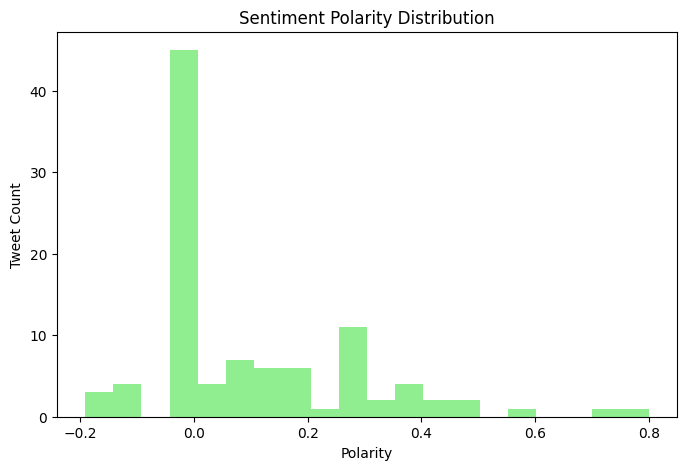

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['polarity'], bins=20, color='lightgreen')
plt.title('Sentiment Polarity Distribution')
plt.xlabel('Polarity')
plt.ylabel('Tweet Count')
plt.show()


In [78]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = re.sub(r'http\S+', '', text)  # Remove URLs
    text = re.sub(r'@\w+', '', text)     # Remove mentions
    text = re.sub(r'#', '', text)        # Remove hashtag symbols
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
    text = text.lower()                  # Lowercase
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]  # Remove stopwords
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(clean_text)
df.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,created_at,text,likes,retweets,polarity,subjectivity,clean_text
0,2025-09-15 17:27:35+00:00,@De_Victoria01 @FractionAI_xyz What I love abo...,0,0,0.26,0.291429,love simple proves showing daily matters fabs ...
1,2025-09-15 17:27:30+00:00,@xAI cut @Grok #AI’s #data team \n\nhttps://t....,0,0,0.00,0.000000,cut ais data team
2,2025-09-15 17:27:29+00:00,@alphadrophunt @FractionAI_xyz @FractionAI_xyz...,0,0,0.30,0.575000,isnt rewarding engagement rewarding consistenc...
3,2025-09-15 17:27:28+00:00,RT @Defi_Diosa23: The future of #AI mobility j...,0,1,0.00,0.125000,rt future ai mobility got started stay heart a...
4,2025-09-15 17:27:25+00:00,RT @ProfIsaPantami: The invention of another w...,0,2,0.00,0.000000,rt invention another world 4ir ai


In [79]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

def analyze_sentiment(text):
    scores = sia.polarity_scores(text)
    return scores['compound']

df['sentiment'] = df['clean_text'].apply(analyze_sentiment)

# Label sentiment
def label_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment_label'] = df['sentiment'].apply(label_sentiment)
df.head()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


,created_at,text,likes,retweets,polarity,subjectivity,clean_text,sentiment,sentiment_label
0,2025-09-15 17:27:35+00:00,@De_Victoria01 @FractionAI_xyz What I love abo...,0,0,0.26,0.291429,love simple proves showing daily matters fabs ...,0.6486,Positive
1,2025-09-15 17:27:30+00:00,@xAI cut @Grok #AI’s #data team \n\nhttps://t....,0,0,0.00,0.000000,cut ais data team,-0.2732,Negative
2,2025-09-15 17:27:29+00:00,@alphadrophunt @FractionAI_xyz @FractionAI_xyz...,0,0,0.30,0.575000,isnt rewarding engagement rewarding consistenc...,-0.6840,Negative
3,2025-09-15 17:27:28+00:00,RT @Defi_Diosa23: The future of #AI mobility j...,0,1,0.00,0.125000,rt future ai mobility got started stay heart a...,0.3818,Positive
4,2025-09-15 17:27:25+00:00,RT @ProfIsaPantami: The invention of another w...,0,2,0.00,0.000000,rt invention another world 4ir ai,0.0000,Neutral


In [80]:
df['sentiment'] = df['clean_text'].apply(analyze_sentiment)
df['sentiment_label'] = df['sentiment'].apply(label_sentiment)


In [81]:
from textblob import TextBlob

def blob_sentiment(text):
    return TextBlob(text).sentiment.polarity

df['blob_sentiment'] = df['clean_text'].apply(blob_sentiment)

def blob_label(score):
    if score > 0:
        return 'Positive'
    elif score < 0:
        return 'Negative'
    else:
        return 'Neutral'

df['blob_sentiment_label'] = df['blob_sentiment'].apply(blob_label)


In [82]:
!pip install streamlit


In [83]:
df.to_csv('tweets_sentiment.csv', index=False)
print("Data saved as tweets_sentiment.csv")


Data saved as tweets_sentiment.csv


In [84]:
%%writefile app.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

st.set_page_config(page_title="Twitter Sentiment Dashboard", layout="wide")

@st.cache_data
def load_data():
    df = pd.read_csv('tweets_sentiment.csv')
    return df

df = load_data()

st.title("📊 Twitter Sentiment Analysis Dashboard")

st.write("### ✅ Sample of the Collected Tweets")
st.dataframe(df[['created_at', 'text', 'sentiment_label']].head())

st.write("### 📈 Sentiment Distribution")
fig, ax = plt.subplots(figsize=(8,4))
sns.countplot(x='sentiment_label', data=df, palette='pastel', ax=ax)
ax.set_title("Tweet Sentiment Breakdown")
st.pyplot(fig)

st.write("### 🔍 Filter Tweets")
sentiment = st.selectbox("Select sentiment", ['All', 'Positive', 'Negative', 'Neutral'])

if sentiment != 'All':
    filtered_df = df[df['sentiment_label'] == sentiment]
else:
    filtered_df = df

st.write(f"### 📰 Showing {sentiment} Tweets")
st.dataframe(filtered_df[['created_at', 'text', 'sentiment']])


Overwriting app.py


In [ ]:
from pyngrok import ngrok
from google.colab import userdata

# Terminate open tunnels if any
ngrok.kill()

# Get the authtoken from Colab secrets and set it
NGROK_AUTH_TOKEN = userdata.get('NGROK_AUTH_TOKEN')
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

# Setup a tunnel to the streamlit port 8501
public_url = ngrok.connect(8501)
print("Public URL:", public_url)

# Run the Streamlit app
!streamlit run app.py --server.port 8501

Public URL: NgrokTunnel: "https://7ef915f8eb5a.ngrok-free.app" -> "http://localhost:8501"



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.10.200.7:8501

/content/app.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment_label', data=df, palette='pastel', ax=ax)
